In [1]:
import os
NUM_THREADS = "4"
os.environ["OMP_NUM_THREADS"] = NUM_THREADS 
os.environ["OPENBLAS_NUM_THREADS"] = NUM_THREADS
os.environ["MKL_NUM_THREADS"] = NUM_THREADS
os.environ["VECLIB_MAXIMUM_THREADS"] = NUM_THREADS
os.environ["NUMEXPR_NUM_THREADS"] = NUM_THREADS

In [2]:
import subprocess
import re
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def compile_run_program(compile_cmd, run_cmd):
    program_output = ""
    compile_process = subprocess.run(compile_cmd, capture_output=True, text=True)

    if compile_process.returncode == 0:        
        # Run the compiled program
        run_process = subprocess.run(run_cmd, capture_output=True, text=True)
        program_output = run_process.stdout
    else:
        print("Compilation failed.")
        print("Compiler output:")
        print(compile_process.stderr)
    return program_output

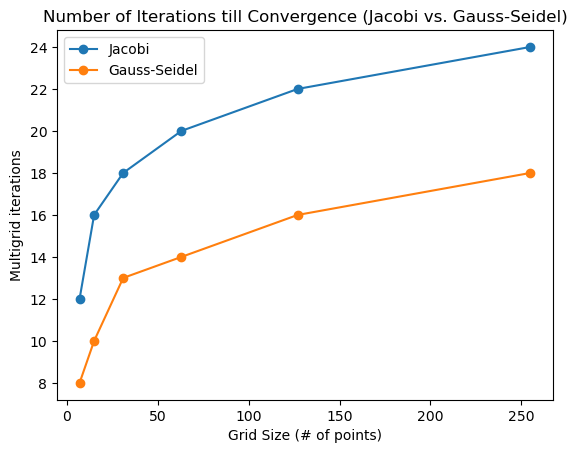

In [4]:
# Define relative paths
SRC_DIR = ".."
PROGRAM = "mg.c"
OUTPUT = "mg.exe"
IMG_OUTPUT = "../images"
IMG = "mg_jacobi_gauss_iter.png"

DIMENSION="2"
GRIDSIZE="15"
LEVELS="4"
SMOOTH_STEPS="2"
SMOOTHER="0"

FLAG_TIME="-time"
FLAG_AVG_TIME="-avg_time"
FLAG_W_CYCLE="-wcycle"
FLAG_F_CYCLE="-fcycle"
FLAG_STENCIL9="-stencil9"

pattern = re.compile(r"Number of iterations of Multi-Grid method: (\d+)")
compile_command = ["gcc", "-g2", "-lm", "-fopenmp", "-I../src_mg", 
                   os.path.join(SRC_DIR, PROGRAM), "-o", os.path.join(SRC_DIR, OUTPUT)]

GRIDSIZES = [str(2**x - 1) for x in range(3,9)] 
iteration_counts = np.zeros((2,len(GRIDSIZES)))

SMOOTHER="0"
for i, GRIDSIZE in enumerate(GRIDSIZES):
    run_command = [os.path.join(SRC_DIR, OUTPUT), DIMENSION, GRIDSIZE, LEVELS, SMOOTH_STEPS, SMOOTHER]
    program_output = compile_run_program(compile_command, run_command)
    match = re.search(pattern, program_output)

    if match:
        iteration_counts[0,i] = int(match.group(1))
    else:
        iteration_counts[0,i] = -1

SMOOTHER="1"
for i, GRIDSIZE in enumerate(GRIDSIZES):
    run_command = [os.path.join(SRC_DIR, OUTPUT), DIMENSION, GRIDSIZE, LEVELS, SMOOTH_STEPS, SMOOTHER]
    program_output = compile_run_program(compile_command, run_command)
    match = re.search(pattern, program_output)

    if match:
        iteration_counts[1,i] = int(match.group(1))
    else:
        iteration_counts[1,i] = -1


plt.plot([int(i) for i in GRIDSIZES], iteration_counts[0,:], label='Jacobi', marker='o')
plt.plot([int(i) for i in GRIDSIZES], iteration_counts[1,:], label='Gauss-Seidel', marker='o')

plt.xlabel('Grid Size (# of points)')
plt.ylabel('Multigrid iterations')
plt.title('Number of Iterations till Convergence (Jacobi vs. Gauss-Seidel)')
plt.legend()

os.makedirs(IMG_OUTPUT, exist_ok=True)
output_file = os.path.join(IMG_OUTPUT, IMG)
plt.savefig(output_file)

plt.show()